# TP4 - Red de Kohonen (SOM)
## Dataset: Características económicas, sociales y geográficas de 28 países de Europa

**Objetivo:** Agrupar países con características similares usando una red neuronal auto-organizada (Self-Organizing Map).

**Variables utilizadas:**
- `Area`: Superficie del país (km²)
- `GDP`: Producto Bruto Interno per cápita (USD)
- `Inflation`: Inflación anual (%)
- `Life.expect`: Expectativa de vida media (años)
- `Military`: Gasto militar (% del GDP)
- `Pop.growth`: Tasa de crecimiento poblacional (%)
- `Unemployment`: Tasa de desempleo (%)

## 1. Importaciones y carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

df = pd.read_csv('europe.csv')
features = ['Area', 'GDP', 'Inflation', 'Life.expect', 'Military', 'Pop.growth', 'Unemployment']
countries = df['Country'].values

X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset: {X_scaled.shape[0]} países, {X_scaled.shape[1]} variables")
df[['Country'] + features]

c:\Users\Yohann Corfdir\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Dataset: 28 países, 7 variables


,Country,Area,GDP,Inflation,Life.expect,Military,Pop.growth,Unemployment
0,Austria,83871,41600,3.5,79.91,0.80,0.03,4.2
1,Belgium,30528,37800,3.5,79.65,1.30,0.06,7.2
2,Bulgaria,110879,13800,4.2,73.84,2.60,-0.80,9.6
3,Croatia,56594,18000,2.3,75.99,2.39,-0.09,17.7
4,Czech Republic,78867,27100,1.9,77.38,1.15,-0.13,8.5
5,Denmark,43094,37000,2.8,78.78,1.30,0.24,6.1
6,Estonia,45228,20400,5.0,73.58,2.00,-0.65,12.5
7,Finland,338145,36000,3.3,79.41,2.00,0.07,7.8
8,Germany,357022,38100,2.5,80.19,1.50,-0.20,6.0
9,Greece,131957,26300,3.3,80.05,4.30,0.06,17.4


## 2. Implementación de la Red de Kohonen (SOM)

### Conceptos clave

- **Grilla**: una cuadrícula de `rows × cols` neuronas. Cada neurona tiene un vector de pesos de dimensión 7 (una por variable).
- **BMU** (Best Matching Unit): la neurona cuyos pesos son más cercanos al dato de entrada (distancia euclídea mínima).
- **Tasa de aprendizaje** `η(t)`: decrece con el tiempo para que la red converja.
- **Radio de vecindad** `σ(t)`: también decrece. Define cuántas neuronas alrededor de la BMU se actualizan.
- **Función de vecindad** `h(t)`: gaussiana, pondera cuánto se actualiza cada neurona según su distancia a la BMU.

### Regla de actualización

Para cada dato `x`, se actualiza el peso `w` de cada neurona `j`:

```
w_j(t+1) = w_j(t) + η(t) · h(r_j, r_bmu, t) · (x - w_j(t))
```

donde `h` es la función gaussiana de vecindad centrada en la BMU.

In [2]:
class SOM:
    def __init__(self, rows, cols, n_features, lr=0.5, sigma=None, n_epochs=500):
        self.rows = rows
        self.cols = cols
        self.n_features = n_features
        self.lr_0 = lr
        self.sigma_0 = sigma if sigma else max(rows, cols) / 2.0
        self.n_epochs = n_epochs

        # Inicializar pesos aleatoriamente
        self.weights = np.random.randn(rows, cols, n_features)

        # Posiciones (fila, col) de cada neurona en la grilla
        self.positions = np.array([[i, j] for i in range(rows) for j in range(cols)])

    def _lr(self, epoch):
        return self.lr_0 * np.exp(-epoch / self.n_epochs)

    def _sigma(self, epoch):
        return self.sigma_0 * np.exp(-epoch / self.n_epochs)

    def _find_bmu(self, x):
        # Distancia euclídea de x a cada neurona
        diff = self.weights - x  # (rows, cols, n_features)
        dist = np.linalg.norm(diff, axis=2)  # (rows, cols)
        bmu_idx = np.unravel_index(np.argmin(dist), (self.rows, self.cols))
        return bmu_idx

    def _neighborhood(self, bmu_pos, sigma):
        bmu_arr = np.array(bmu_pos)
        # Distancia euclídea de cada neurona a la BMU en la grilla
        dists_sq = np.sum((self.positions - bmu_arr) ** 2, axis=1)
        h = np.exp(-dists_sq / (2 * sigma ** 2))
        return h.reshape(self.rows, self.cols)

    def train(self, X):
        n_samples = X.shape[0]
        for epoch in range(self.n_epochs):
            lr = self._lr(epoch)
            sigma = self._sigma(epoch)
            # Iterar sobre datos en orden aleatorio
            for idx in np.random.permutation(n_samples):
                x = X[idx]
                bmu = self._find_bmu(x)
                h = self._neighborhood(bmu, sigma)
                # Actualizar pesos: w += lr * h * (x - w)
                self.weights += lr * h[:, :, np.newaxis] * (x - self.weights)

    def predict(self, X):
        return [self._find_bmu(x) for x in X]

    def umatrix(self):
        u = np.zeros((self.rows, self.cols))
        for i in range(self.rows):
            for j in range(self.cols):
                neighbors = []
                for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                    ni, nj = i+di, j+dj
                    if 0 <= ni < self.rows and 0 <= nj < self.cols:
                        d = np.linalg.norm(self.weights[i, j] - self.weights[ni, nj])
                        neighbors.append(d)
                u[i, j] = np.mean(neighbors)
        return u


# Entrenar la SOM con grilla 4x4
som = SOM(rows=4, cols=4, n_features=X_scaled.shape[1], lr=0.5, n_epochs=1000)
som.train(X_scaled)
print("Entrenamiento completado.")

Entrenamiento completado.


## 3. Asignación de países a neuronas

In [3]:
# Asignar cada país a su BMU
bmu_list = som.predict(X_scaled)

# Construir diccionario: (fila, col) -> lista de países
neuron_map = {}
for country, bmu in zip(countries, bmu_list):
    neuron_map.setdefault(bmu, []).append(country)

print("Países asignados a cada neurona:\n")
for (i, j), paises in sorted(neuron_map.items()):
    print(f"  Neurona ({i},{j}): {', '.join(paises)}")

Países asignados a cada neurona:

  Neurona (0,0): Croatia, Slovenia
  Neurona (0,1): Czech Republic
  Neurona (0,2): Iceland, Ireland
  Neurona (0,3): Luxembourg, Switzerland
  Neurona (1,0): Lithuania, Slovakia
  Neurona (1,2): Austria, Belgium, Denmark, Netherlands
  Neurona (1,3): Norway
  Neurona (2,0): Bulgaria, Estonia, Latvia
  Neurona (2,1): Hungary
  Neurona (2,3): Finland, Germany, Italy, Sweden
  Neurona (3,0): Ukraine
  Neurona (3,1): Poland
  Neurona (3,2): Greece, Portugal, United Kingdom
  Neurona (3,3): Spain


## 4. Gráfico: Mapa de países en la grilla SOM

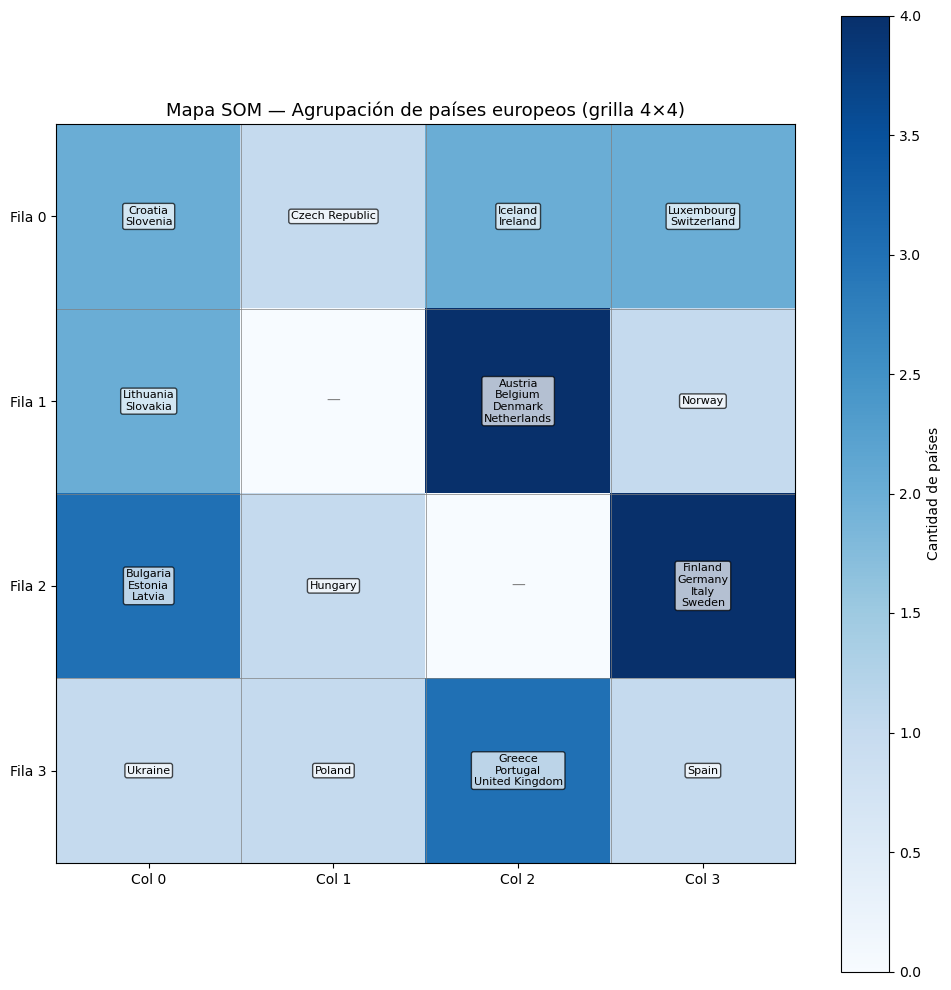

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))

rows, cols = som.rows, som.cols

# Fondo: cantidad de países por neurona
count_grid = np.zeros((rows, cols))
for (i, j), paises in neuron_map.items():
    count_grid[i, j] = len(paises)

im = ax.imshow(count_grid, cmap='Blues', vmin=0, vmax=count_grid.max(), aspect='equal')
plt.colorbar(im, ax=ax, label='Cantidad de países')

# Escribir los nombres de países en cada celda
for (i, j), paises in neuron_map.items():
    text = '\n'.join(paises)
    ax.text(j, i, text, ha='center', va='center', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Neuronas vacías
for i in range(rows):
    for j in range(cols):
        if (i, j) not in neuron_map:
            ax.text(j, i, '—', ha='center', va='center', fontsize=10, color='gray')

ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.set_xticklabels([f'Col {j}' for j in range(cols)])
ax.set_yticklabels([f'Fila {i}' for i in range(rows)])
ax.set_title('Mapa SOM — Agrupación de países europeos (grilla 4×4)', fontsize=13)

# Grilla
for i in range(rows + 1):
    ax.axhline(i - 0.5, color='gray', linewidth=0.5)
for j in range(cols + 1):
    ax.axvline(j - 0.5, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

## 5. Gráfico: U-Matrix (distancias promedio entre neuronas vecinas)

La **U-Matrix** (Unified Distance Matrix) muestra la distancia promedio entre los pesos de cada neurona y sus vecinas directas (arriba, abajo, izquierda, derecha).

- **Color claro**: neuronas cercanas entre sí → zona de un mismo cluster.
- **Color oscuro**: neuronas muy distintas entre sí → frontera entre clusters.

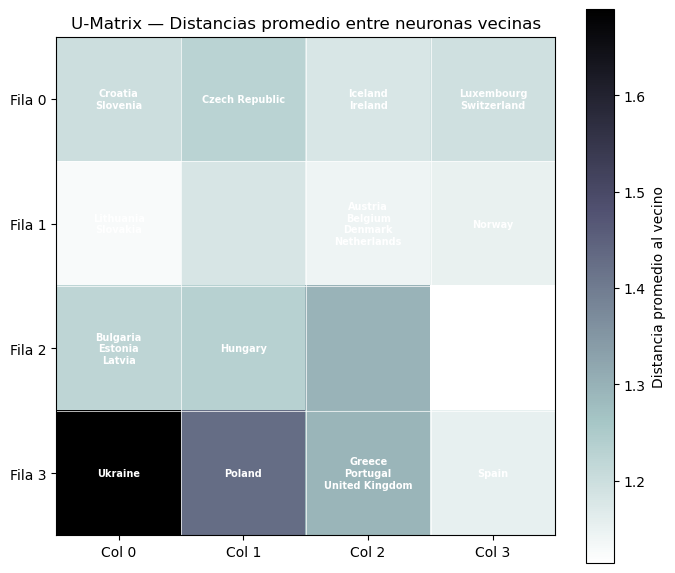


Valores de la U-Matrix:
        Col 0  Col 1  Col 2  Col 3
Fila 0  1.198  1.228  1.179  1.195
Fila 1  1.126  1.181  1.143  1.152
Fila 2  1.221  1.231  1.294  1.114
Fila 3  1.690  1.429  1.293  1.154


In [5]:
u_matrix = som.umatrix()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(u_matrix, cmap='bone_r', aspect='equal')
plt.colorbar(im, ax=ax, label='Distancia promedio al vecino')

# Superponer nombres de países
for (i, j), paises in neuron_map.items():
    text = '\n'.join(paises)
    ax.text(j, i, text, ha='center', va='center', fontsize=7,
            color='white', fontweight='bold')

ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.set_xticklabels([f'Col {j}' for j in range(cols)])
ax.set_yticklabels([f'Fila {i}' for i in range(rows)])
ax.set_title('U-Matrix — Distancias promedio entre neuronas vecinas', fontsize=12)

for i in range(rows + 1):
    ax.axhline(i - 0.5, color='white', linewidth=0.5)
for j in range(cols + 1):
    ax.axvline(j - 0.5, color='white', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nValores de la U-Matrix:")
print(pd.DataFrame(u_matrix.round(3),
                   index=[f'Fila {i}' for i in range(rows)],
                   columns=[f'Col {j}' for j in range(cols)]))

## 6. Análisis: cantidad de países por neurona

Total de neuronas en la grilla 4×4: 16
Neuronas con al menos un país asignado: 14
Neuronas vacías: 2

Neurona  Cantidad                                 Países
  (1,2)         4 Austria, Belgium, Denmark, Netherlands
  (2,3)         4        Finland, Germany, Italy, Sweden
  (2,0)         3              Bulgaria, Estonia, Latvia
  (3,2)         3       Greece, Portugal, United Kingdom
  (0,0)         2                      Croatia, Slovenia
  (0,2)         2                       Iceland, Ireland
  (0,3)         2                Luxembourg, Switzerland
  (1,0)         2                    Lithuania, Slovakia
  (0,1)         1                         Czech Republic
  (1,3)         1                                 Norway
  (2,1)         1                                Hungary
  (3,0)         1                                Ukraine
  (3,1)         1                                 Poland
  (3,3)         1                                  Spain


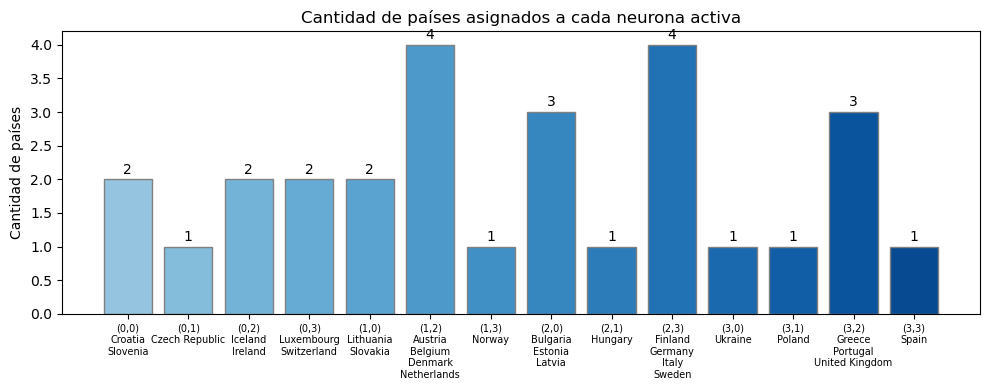

In [6]:
total_neuronas = som.rows * som.cols
neuronas_activas = len(neuron_map)
neuronas_vacias = total_neuronas - neuronas_activas

print(f"Total de neuronas en la grilla 4×4: {total_neuronas}")
print(f"Neuronas con al menos un país asignado: {neuronas_activas}")
print(f"Neuronas vacías: {neuronas_vacias}")
print()

# Tabla de distribución
rows_tabla = []
for (i, j) in sorted(neuron_map.keys()):
    paises = neuron_map[(i, j)]
    rows_tabla.append({
        'Neurona': f'({i},{j})',
        'Cantidad': len(paises),
        'Países': ', '.join(paises)
    })

tabla = pd.DataFrame(rows_tabla).sort_values('Cantidad', ascending=False).reset_index(drop=True)
print(tabla.to_string(index=False))

# Gráfico de barras
fig, ax = plt.subplots(figsize=(10, 4))
etiquetas = [f"({i},{j})\n" + '\n'.join(neuron_map[(i,j)]) for (i,j) in sorted(neuron_map.keys())]
cantidades = [len(neuron_map[(i,j)]) for (i,j) in sorted(neuron_map.keys())]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(cantidades)))
bars = ax.bar(range(len(cantidades)), cantidades, color=colors, edgecolor='gray')
ax.set_xticks(range(len(etiquetas)))
ax.set_xticklabels(etiquetas, fontsize=7)
ax.set_ylabel('Cantidad de países')
ax.set_title('Cantidad de países asignados a cada neurona activa')
ax.bar_label(bars, padding=2)
plt.tight_layout()
plt.show()

## 7. Análisis de resultados

### Resultados de la asignación

La SOM entrenada sobre los 28 países europeos produjo la siguiente distribución en la grilla 4×4:

| Neurona | Países asignados | Característica principal |
|---------|-----------------|--------------------------|
| (0,3) | Luxembourg, Switzerland | GDP altísimo (80600 y 44500), inflación muy baja |
| (1,3) | Norway | GDP muy alto (53400), inflación bajísima (1.3%) |
| (1,2) | Austria, Belgium, Denmark, Netherlands | Europa occidental rica, baja inflación y desempleo |
| (2,3) | Finland, Germany, Italy, Sweden | Países grandes con GDP alto y alta expectativa de vida |
| (0,2) | Iceland, Ireland | GDP alto con crecimiento poblacional positivo elevado |
| (0,0) | Croatia, Slovenia | Europa central-este, GDP y desempleo intermedios |
| (0,1) | Czech Republic | GDP intermedio, inflación baja (1.9%) |
| (1,0) | Lithuania, Slovakia | GDP bajo, alta inflación y desempleo |
| (2,0) | Bulgaria, Estonia, Latvia | Europa del Este: GDP bajo (~14000-20000), inflación alta |
| (2,1) | Hungary | Perfil único: GDP bajo con alta tasa de desempleo |
| (3,1) | Poland | Área enorme, GDP bajo, pop.growth negativo |
| (3,2) | Greece, Portugal, United Kingdom | Desempleo moderado-alto, GDP intermedio |
| (3,3) | Spain | Área enorme (505370 km²), desempleo más alto del dataset (21.7%) |
| (3,0) | Ukraine | Outlier: GDP bajísimo (7200), inflación máxima (8%), área enorme |

### Interpretación de la topología

La SOM organizó los países siguiendo un **gradiente económico claro de izquierda a derecha**:
- **Columna 0** (izquierda): países con menor GDP y mayor inestabilidad económica (Europa del Este y Ucrania).
- **Columna 3** (derecha): países con mayor GDP y mayor estabilidad (Luxemburgo, Suiza, Noruega, Alemania).

De arriba a abajo, el gradiente responde al **área geográfica y características demográficas**:
- **Fila 0**: países pequeños o medianos con perfiles intermedios.
- **Filas 2-3**: países grandes (Ucrania, Polonia, España, Finlandia, Alemania) o con características extremas.

### Agrupaciones más relevantes

- **Luxembourg y Switzerland (0,3)**: agrupación muy acertada — ambos países tienen los GDP más altos del dataset y la inflación más baja. Son los países más ricos y estables de Europa.
- **Austria, Belgium, Denmark, Netherlands (1,2)**: el "núcleo" de Europa occidental, todos con GDP ~37000-42000 y bajo desempleo.
- **Bulgaria, Estonia, Latvia (2,0)**: los tres países bálticos/del Este con menor PIB y mayor inflación, correctamente agrupados.
- **Ukraine (3,0)**: neurona propia como outlier extremo — GDP de 7200 (el mínimo), inflación de 8% (la máxima) y el área más grande del dataset.

### Caso interesante: Italy con Finland, Germany, Sweden (2,3)

Italia parece diferente a Finlandia, Alemania y Suecia, pero comparte con ellos la **mayor expectativa de vida del dataset** (81.86 años), área geográfica grande y un GDP en rango similar (30500 vs 36000-38100). La SOM encontró esta similitud que no es evidente a simple vista.

### Caso interesante: Greece, Portugal, United Kingdom (3,2)

Esta agrupación refleja que los tres países comparten un **desempleo moderado-alto** (17.4%, 12.7% y 8.1%) y un GDP similar en el rango intermedio. Grecia arrastra su crisis económica de los 2010s (datos de 2012-2013).

### Distribución por neurona

- **16 neuronas** en total, **14 activas** (87.5% de utilización), **2 vacías**: (1,1) y (2,2).
- Las 2 neuronas vacías indican que en este dataset no existe un perfil de país que corresponda a esas posiciones intermedias en la grilla.
- Las neuronas con más países (Austria/Belgium/Denmark/Netherlands y Finland/Germany/Italy/Sweden con 4 países cada una) representan los perfiles más "típicos" o más frecuentes en Europa.